In [ ]:
import os

# Ensure relative paths resolve from the snapViT project directory.
os.chdir("/home/ale_navone/ws_pytorch/GAIA/snapViT")

# ============================================================
# CONFIGURATION — edit this cell to add / remove model runs.
# Each entry needs:
#   "folder" : path to the evaluation folder containing
#              cosine_per_scene.csv  (relative to snapViT/ or
#              absolute)
#   "name"   : human-readable label shown in plot titles
# ============================================================
model_configs = [
    #{
    #    "folder": "evaluation/rete_consecutiva",
    #    "name": "Consecutive Frames Training",
    #},
    #{
    #    "folder": "evaluation/rete_random",
    #    "name": "Random Frames Training",
    #},
    {
        "folder": "evaluation/rete_consecutiva_test",
        "name": "Consecutive Frames Testing",
    },
    {
        "folder": "evaluation/rete_random_test",
        "name": "Random Frames Testing",
    },
    {
        "folder": "evaluation/rete_consecutive_global_loss",
        "name": "Consecutive Frames Testing with Global Loss",
    },
    {
        "folder": "evaluation/random_frames_mixed_loss_lambda_0_5",
        "name": "Random Frames Testing with Mixed Loss",
    }

    
    # Example: add more models here
    # {
    #     "folder": "evaluation/my_new_model",
    #     "name": "My New Model",
    # },
]


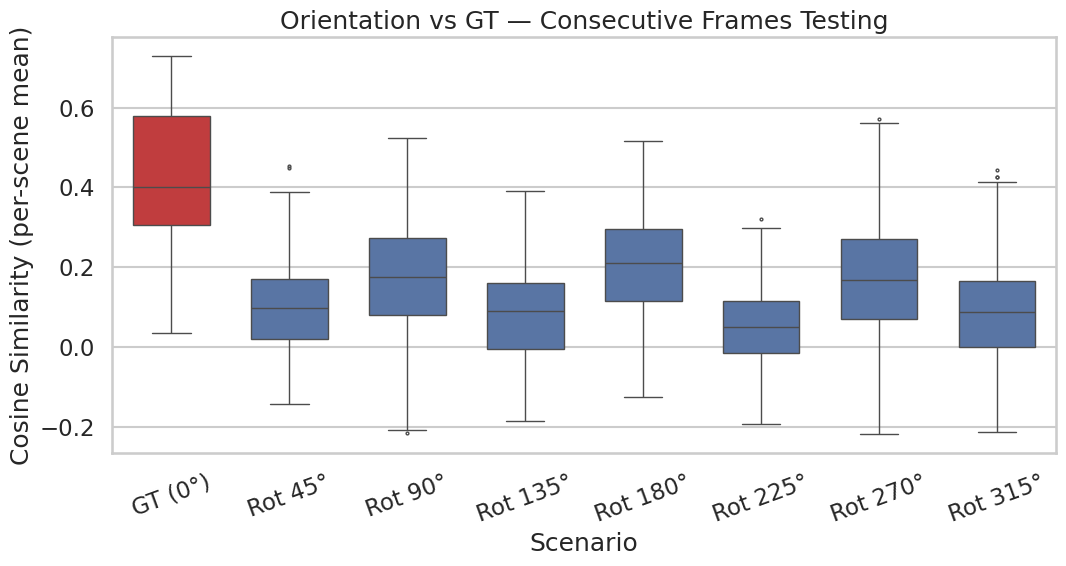

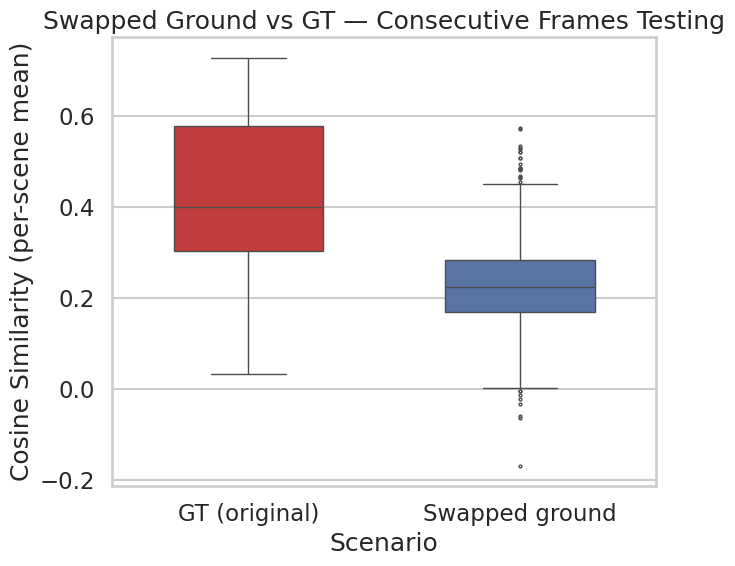

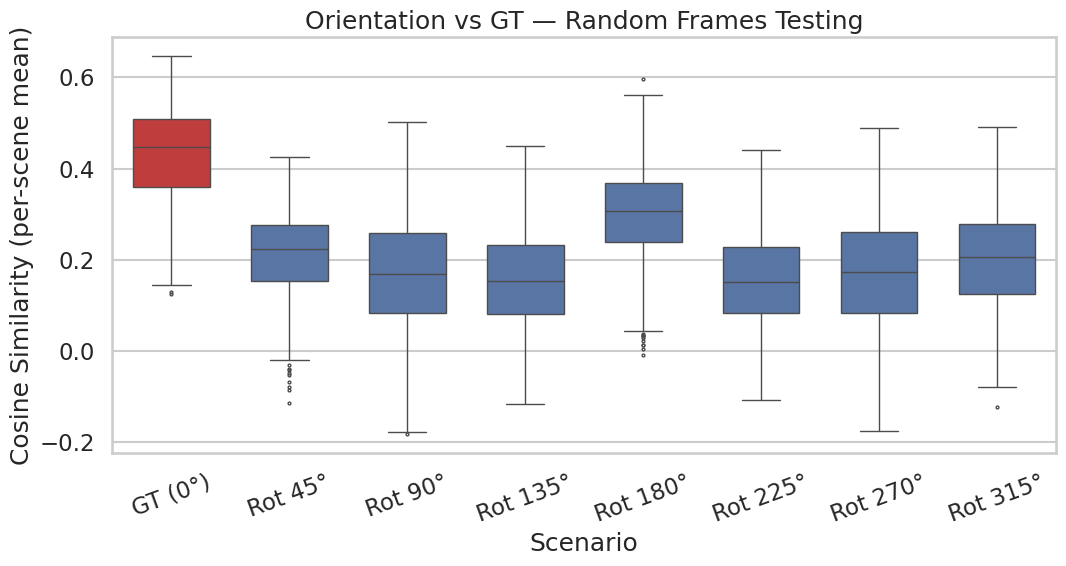

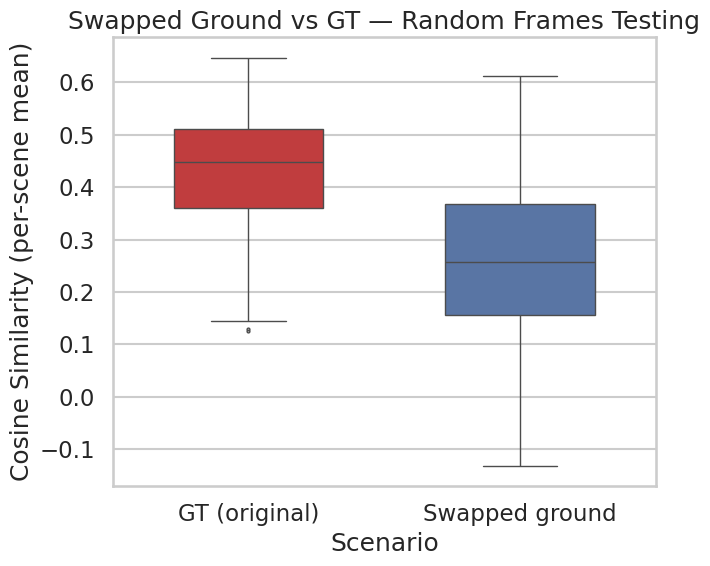

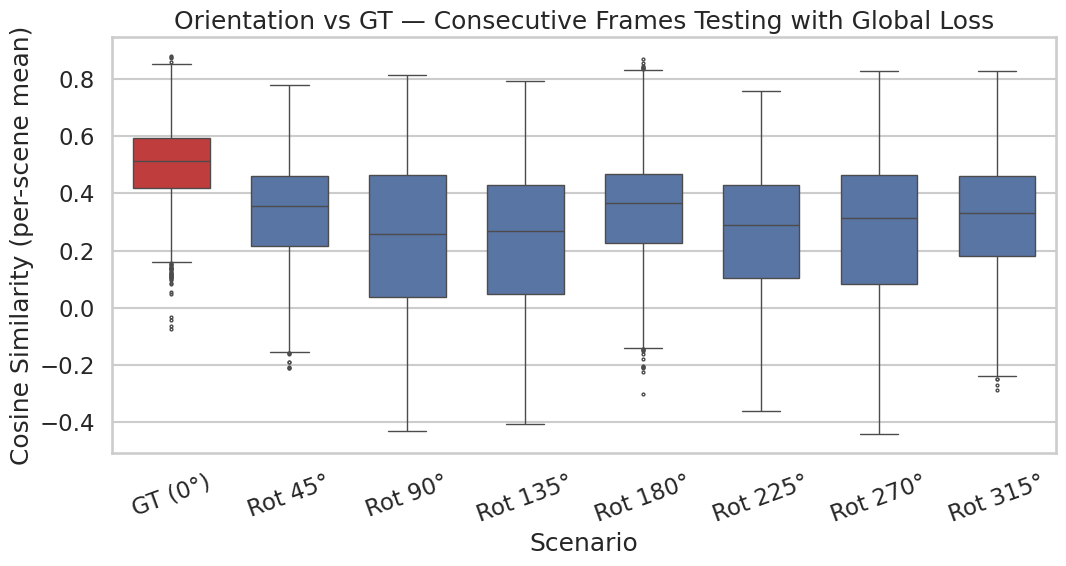

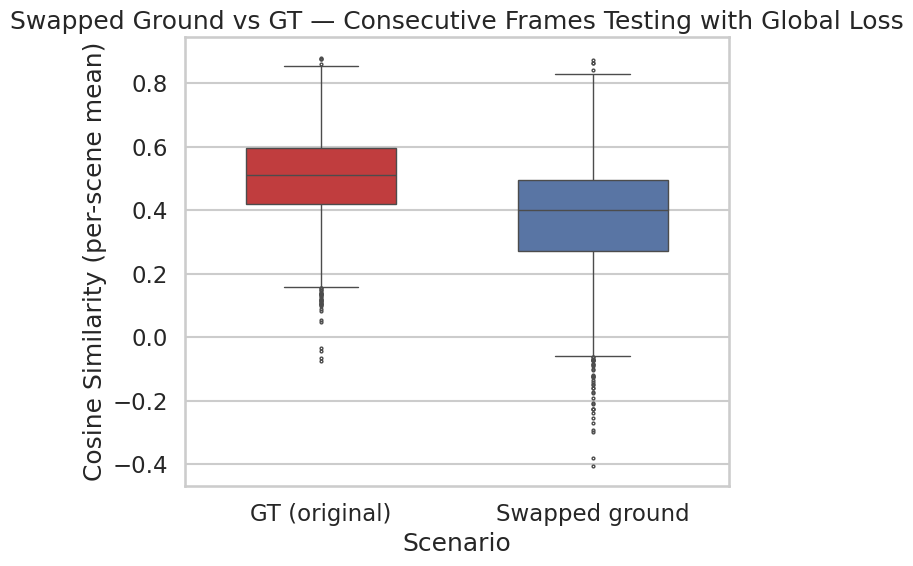

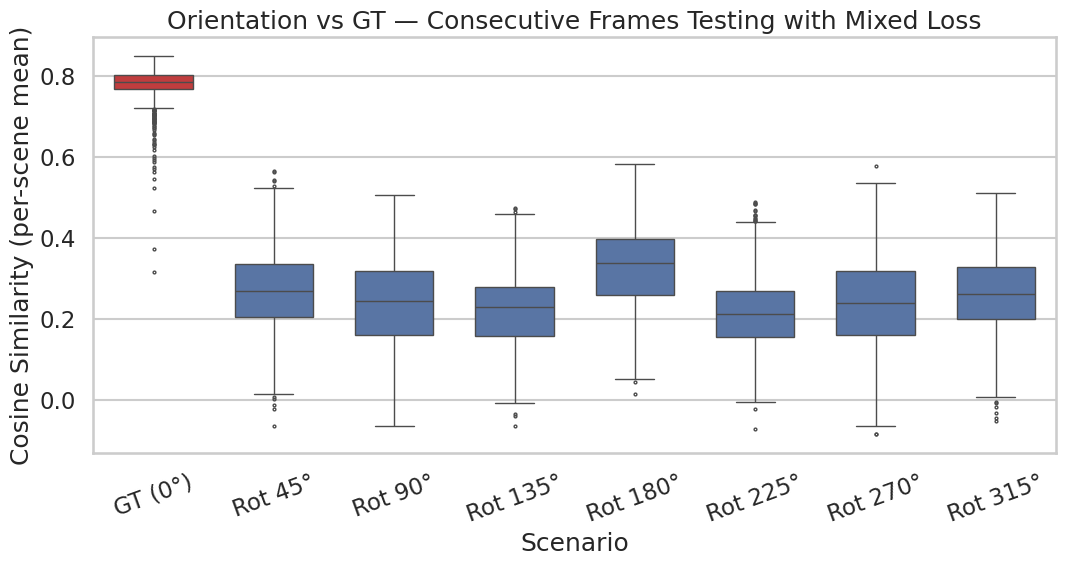

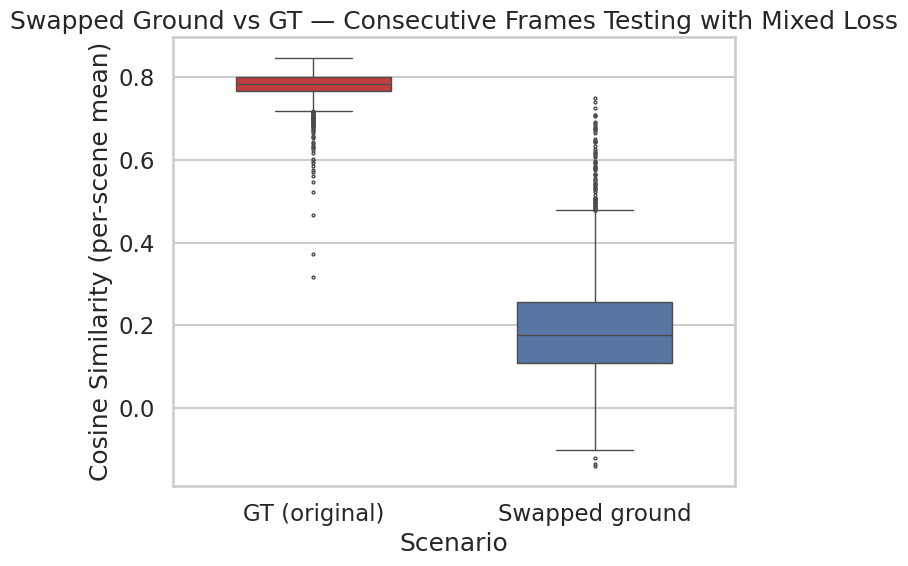

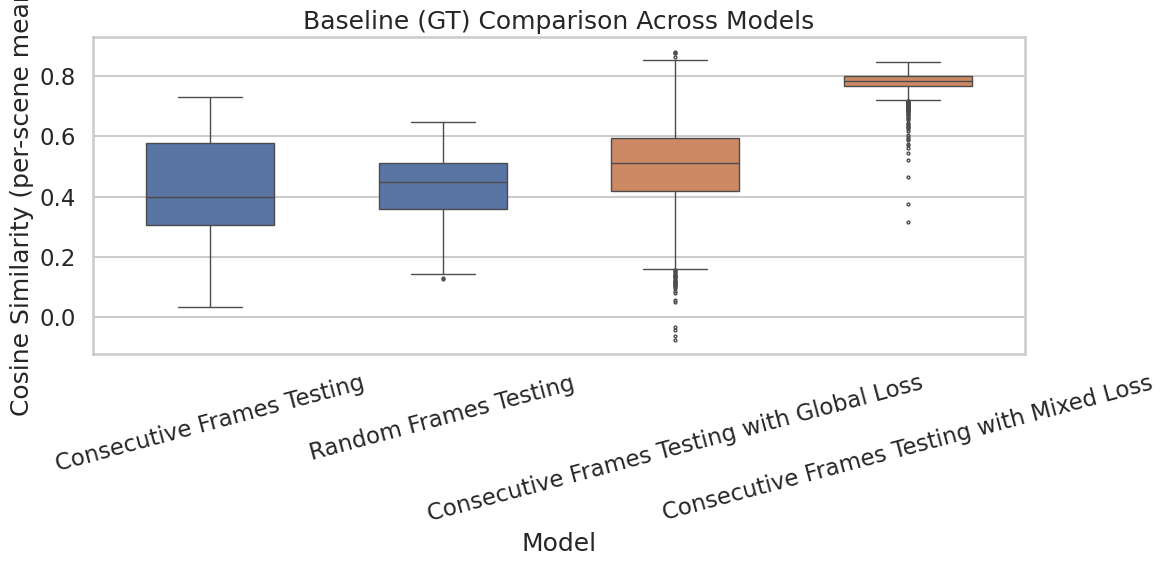

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ----- Scenario definitions -----
ORIENTATION_ORDER = [
    "baseline",
    "ground_rot_45",
    "ground_rot_90",
    "ground_rot_135",
    "ground_rot_180",
    "ground_rot_225",
    "ground_rot_270",
    "ground_rot_315",
]
ORIENTATION_LABELS = {
    "baseline": "GT (0°)",
    "ground_rot_45": "Rot 45°",
    "ground_rot_90": "Rot 90°",
    "ground_rot_135": "Rot 135°",
    "ground_rot_180": "Rot 180°",
    "ground_rot_225": "Rot 225°",
    "ground_rot_270": "Rot 270°",
    "ground_rot_315": "Rot 315°",
}

# Only baseline vs pure swap (no rotated+swapped variants).
SWAPPED_ORDER = ["baseline", "ground_swap"]
SWAPPED_LABELS = {
    "baseline": "GT (original)",
    "ground_swap": "Swapped ground",
}

GT_COLOR     = "#d62728"   # red  — ground truth
ALT_COLOR    = "#4c72b0"   # blue — other scenarios
MODEL_COLOR1 = "#4c72b0"   # blue — first half of models
MODEL_COLOR2 = "#dd8452"   # orange — second half of models

sns.set_theme(style="whitegrid", context="talk")

# Collect baseline rows from each model for the cross-model comparison.
baseline_frames = []

# ----- Loop over model configs -----
for cfg in model_configs:
    folder = Path(cfg["folder"])
    name   = cfg["name"]

    csv_path = folder / "cosine_per_scene.csv"
    if not csv_path.exists():
        print(f"[SKIP] {csv_path} not found — skipping '{name}'.")
        continue

    df = pd.read_csv(csv_path)
    # Exclude scenes with no valid pixels.
    df = df[df["valid_pixels"] > 0].copy()

    # ---------- Plot 1: Orientation vs GT ----------
    orient_df = df[df["scenario"].isin(ORIENTATION_ORDER)].copy()
    orient_df["label"] = orient_df["scenario"].map(ORIENTATION_LABELS)
    ordered_orient = [ORIENTATION_LABELS[s] for s in ORIENTATION_ORDER if ORIENTATION_LABELS[s] in orient_df["label"].values]
    palette_orient = {ORIENTATION_LABELS["baseline"]: GT_COLOR}
    palette_orient.update({ORIENTATION_LABELS[s]: ALT_COLOR for s in ORIENTATION_ORDER[1:]})

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.boxplot(
        data=orient_df,
        x="label",
        y="mean",
        hue="label",
        order=ordered_orient,
        hue_order=ordered_orient,
        palette=palette_orient,
        width=0.65,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Orientation vs GT — {name}")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    # ---------- Plot 2: Swapped ground vs GT ----------
    swapped_df = df[df["scenario"].isin(SWAPPED_ORDER)].copy()
    swapped_df["label"] = swapped_df["scenario"].map(SWAPPED_LABELS)
    ordered_swapped = [SWAPPED_LABELS[s] for s in SWAPPED_ORDER]
    palette_swapped = {SWAPPED_LABELS["baseline"]: GT_COLOR, SWAPPED_LABELS["ground_swap"]: ALT_COLOR}

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.boxplot(
        data=swapped_df,
        x="label",
        y="mean",
        hue="label",
        order=ordered_swapped,
        hue_order=ordered_swapped,
        palette=palette_swapped,
        width=0.55,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Swapped Ground vs GT — {name}")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    plt.tight_layout()
    plt.show()

    # Accumulate baseline rows for cross-model comparison.
    base_rows = df[df["scenario"] == "baseline"].copy()
    base_rows["model"] = name
    baseline_frames.append(base_rows)

# ---------- Plot 3: Baseline comparison across models ----------
if len(baseline_frames) >= 2:
    baseline_all = pd.concat(baseline_frames, ignore_index=True)
    model_names  = [cfg["name"] for cfg in model_configs if (Path(cfg["folder"]) / "cosine_per_scene.csv").exists()]

    half = len(model_names) // 2
    palette_models = {
        n: MODEL_COLOR1 if i < half else MODEL_COLOR2
        for i, n in enumerate(model_names)
    }

    fig, ax = plt.subplots(figsize=(max(7, 3 * len(model_names)), 6))
    sns.boxplot(
        data=baseline_all,
        x="model",
        y="mean",
        hue="model",
        order=model_names,
        hue_order=model_names,
        palette=palette_models,
        width=0.55,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title("Baseline (GT) Comparison Across Models")
    ax.set_xlabel("Model")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
elif len(baseline_frames) == 1:
    print("[INFO] Only one model loaded — cross-model comparison skipped.")
